In [2]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
import numpy as np
import matplotlib.pyplot as plt
import thinkplot
import scipy.signal
import ipywidgets as widgets

from thinkdsp import decorate, SquareSignal, Wave, zero_pad
from ipywidgets import interact, interactive, fixed

Упражнение 8.1

In [4]:
def create_boxcar_filter(size=11):
    boxcar = np.ones(size)
    boxcar /= sum(boxcar)
    return boxcar

def create_gaussian_filter(size=11, std=2):
    gaussian = scipy.signal.windows.gaussian(M=size, std=std)
    gaussian /= sum(gaussian)
    return gaussian

def apply_filter_and_plot(wave, filter_kernel, filter_label, amp_threshold=560):
    ys = np.convolve(wave.ys, filter_kernel, mode='same')
    smooth = Wave(ys, framerate=wave.framerate)

    spectrum = wave.make_spectrum()
    spectrum2 = smooth.make_spectrum()
 
    amps = spectrum.amps
    amps2 = spectrum2.amps
    ratio = amps2 / amps    
    ratio[amps < amp_threshold] = 0

    padded = zero_pad(filter_kernel, len(wave))
    dft_filter = np.fft.rfft(padded)

    plt.plot(np.abs(dft_filter), color='0.7', label=f'Фильтр {filter_label}')
    plt.plot(ratio, label='Амплитуда')

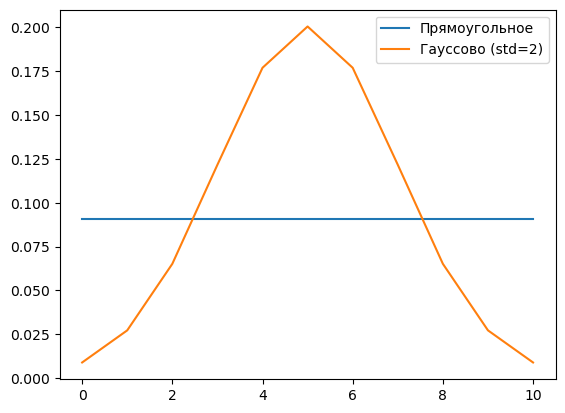

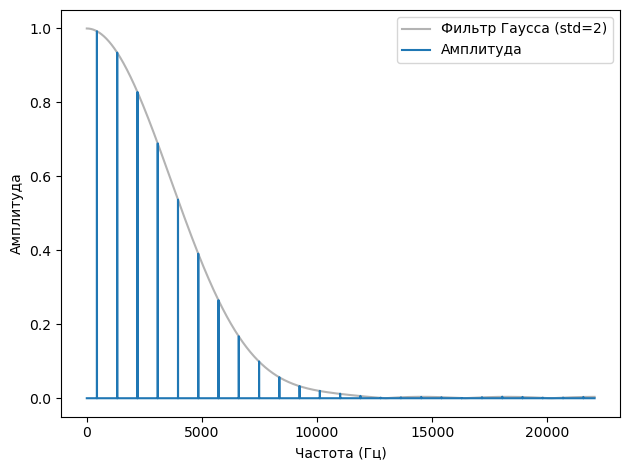

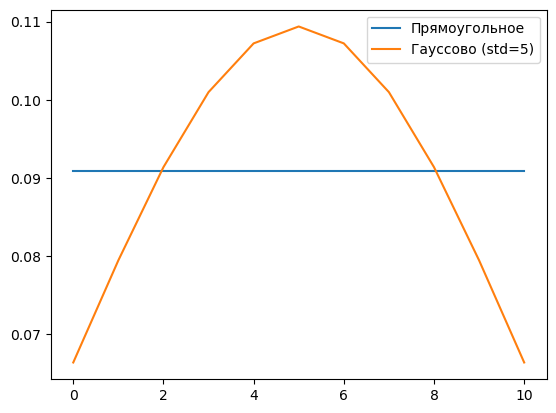

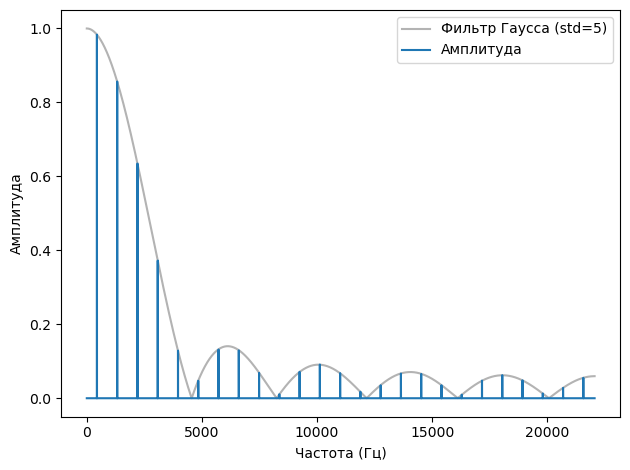

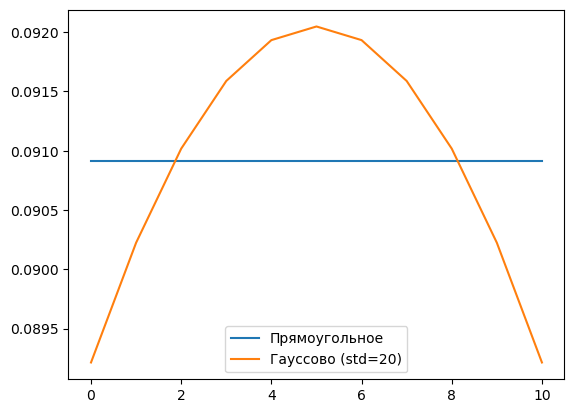

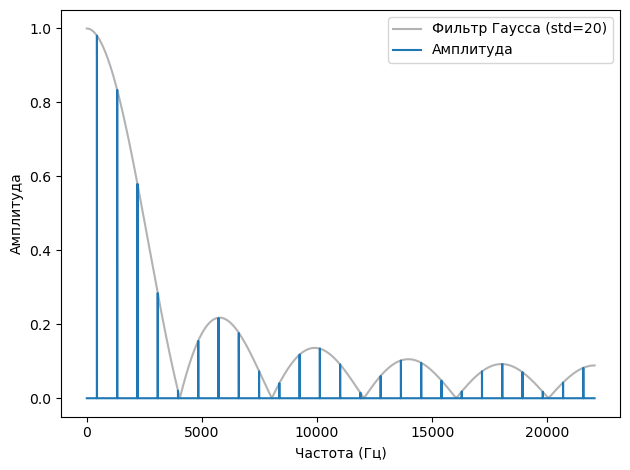

In [5]:
def analyze_filters(std_values=[2, 5, 20], size=11):
    boxcar = create_boxcar_filter(size)

    signal = SquareSignal(freq=440)
    wave = signal.make_wave(duration=1, framerate=44100)
    
    for std in std_values:
        gaussian = create_gaussian_filter(size, std)
        plt.plot(boxcar, label='Прямоугольное')
        plt.plot(gaussian, label=f'Гауссово (std={std})')
        plt.legend()
        plt.show()
        
        apply_filter_and_plot(wave, gaussian, f'Гаусса (std={std})')
        decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')
        plt.legend()
        plt.show()

analyze_filters()

Упражнение 8.2

In [7]:
def gaussian_curve(std, M=30):

    gauss_window = scipy.signal.windows.gaussian(M=M, std=std)
    gauss_window /= sum(gauss_window)
    
    plt.plot(gauss_window, label=f'std={std}')
    decorate(xlabel='Время (с)', title='Окно Гаусса')
    plt.show()
    
    fft_gaussian = np.fft.fft(gauss_window)
    fft_shifted = np.fft.fftshift(fft_gaussian)
    freqs = np.fft.fftshift(np.fft.fftfreq(M))
    

    plt.plot(freqs, np.abs(fft_shifted), label=f'std={std}')
    decorate(xlabel='Частота', title='ДПФ')

    plt.show()
    
    return gauss_window, fft_shifted

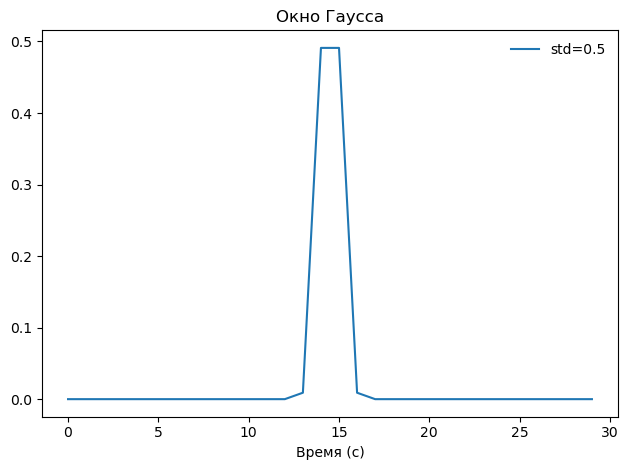

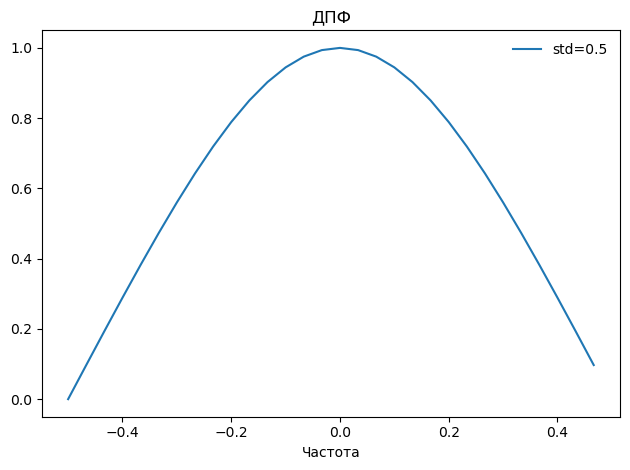

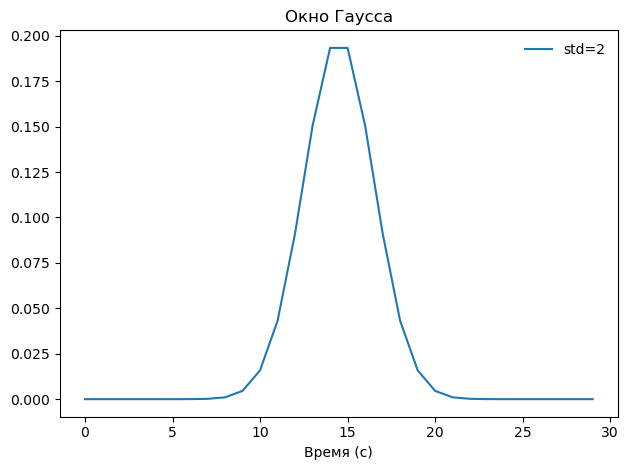

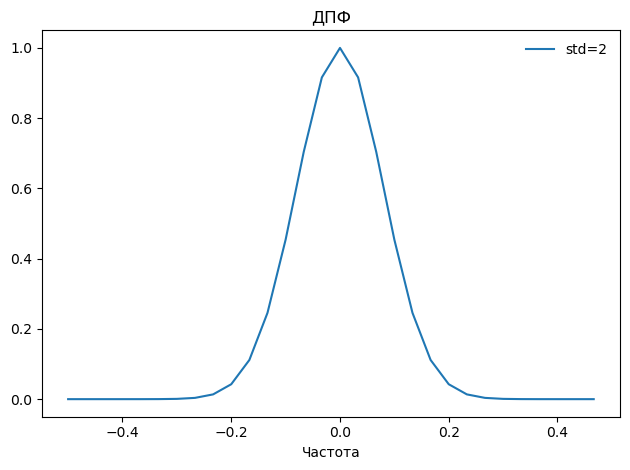

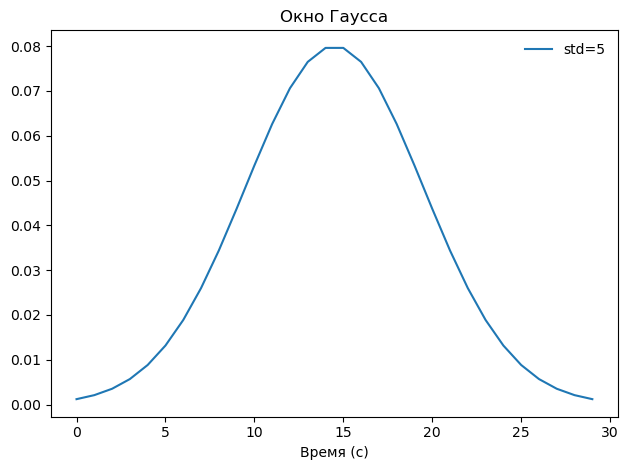

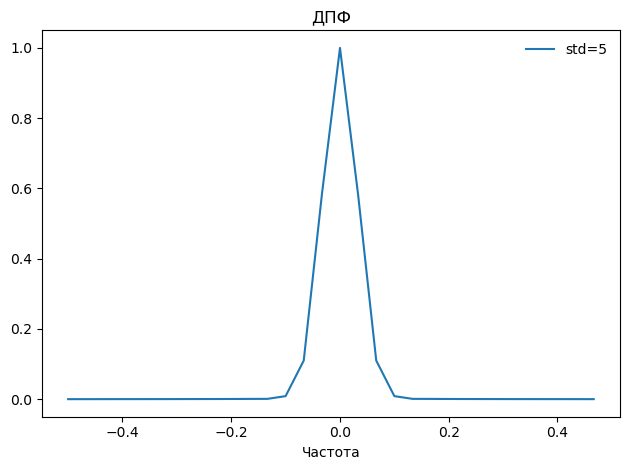

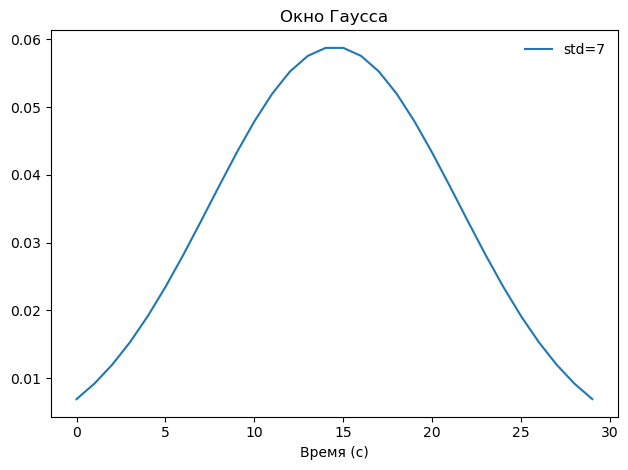

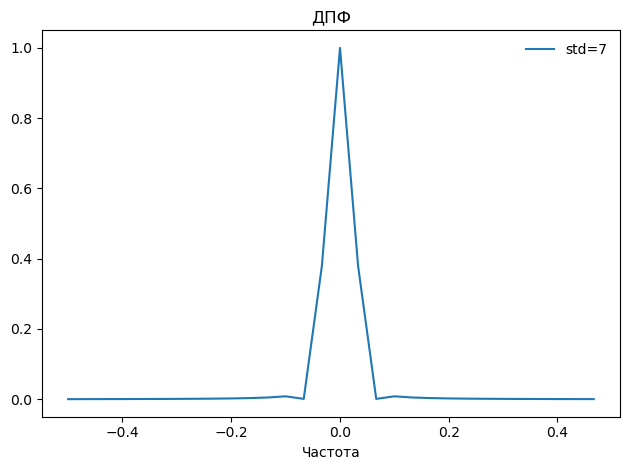

In [8]:
def analyze_curve(std_values=[0.5, 2, 5, 7], size=30):
    
    for std in std_values:
        gauss_window, fft_shifted = gaussian_curve(std, size)

analyze_curve()

Упражнение 8.3

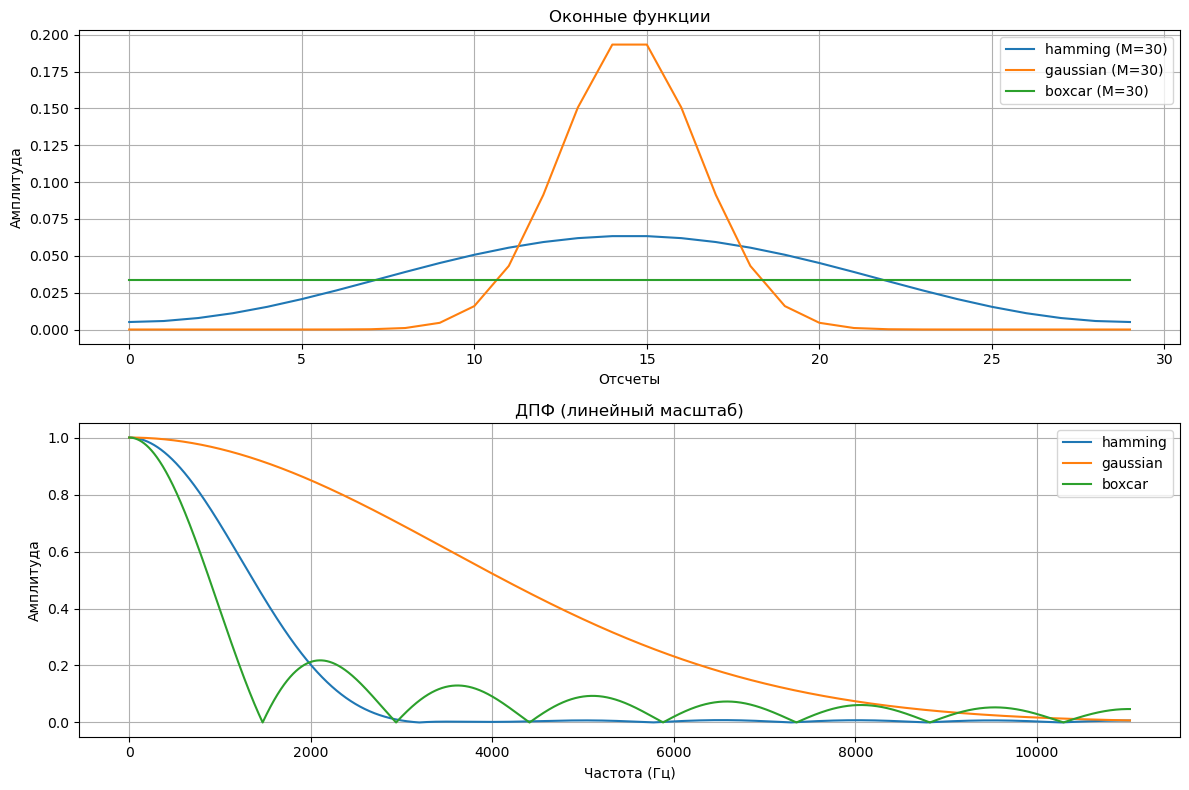

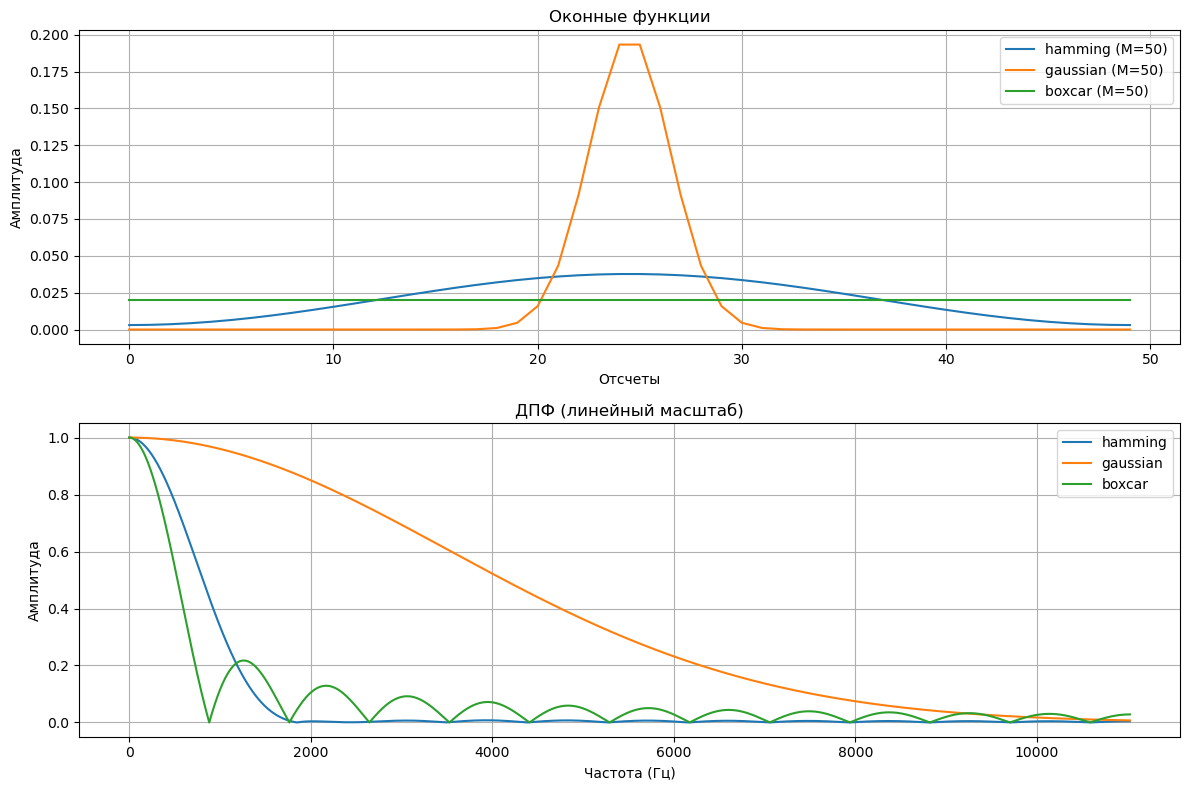

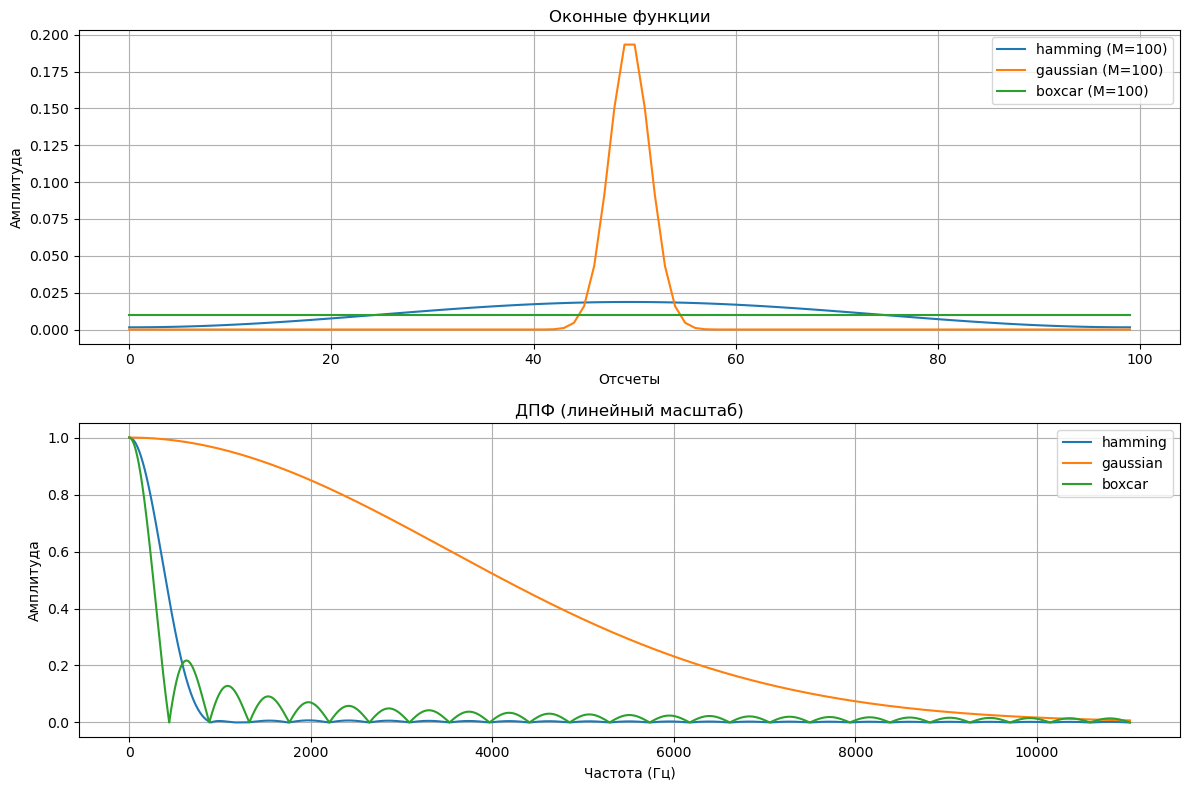

In [10]:
def analyze_window_functions(window_types=['hamming', 'gaussian', 'boxcar'], 
                           M=30, std=2, duration=1.0, framerate=44100):
    signal = SquareSignal(freq=440)
    wave = signal.make_wave(duration=duration, framerate=framerate)
    plt.figure(figsize=(12, 8))
    
    for window_type in window_types:
        if window_type == 'gaussian':
            window = scipy.signal.windows.gaussian(M, std)
        elif window_type == 'hamming':
            window = np.hamming(M)
        elif window_type == 'boxcar':
            window = np.ones(M)
        else:
            continue
            
        window /= np.sum(window)
        
        padded = zero_pad(window, len(wave))
        dft = np.fft.rfft(padded)
        freqs = np.fft.rfftfreq(len(padded), 1/framerate)
        
        plt.subplot(2, 1, 1)
        plt.plot(window, label=f'{window_type} (M={M})')
        decorate(title=('Оконные функции'), xlabel=('Отсчеты'),ylabel=('Амплитуда'))
        plt.legend()
        plt.grid(True)

        plt.subplot(2, 1, 2)
        plt.plot(freqs[:len(dft)//2], np.abs(dft[:len(dft)//2]), 
                     label=f'{window_type}')
        decorate(title=('ДПФ (линейный масштаб)'), xlabel=('Частота (Гц)'),ylabel=('Амплитуда'))
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

for M in [30, 50, 100]:
    analyze_window_functions(window_types=['hamming', 'gaussian', 'boxcar'], 
                           M=M, std=2)